<a href="https://colab.research.google.com/github/Tulin206/erumhub_deep-learning_2026/blob/main/code/FCNN/04_mnist_classification_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Deep Learning with TensorFlow

This notebook implements a basic deep learning model using TensorFlow/Keras to classify MNIST digits. We'll cover:
- Building a simple neural network
- Training and validation process
- Performance visualization

## What is Deep Learning?
Deep learning is a branch of machine learning that uses artificial neural networks to learn patterns from data. In this notebook, we'll teach a computer to recognize handwritten digits (0-9) by learning from thousands of examples.

## What is MNIST?
MNIST is a famous dataset containing 70,000 images of handwritten digits. Each image is 28×28 pixels (784 pixels total). Our neural network will learn to recognize these digits by finding patterns in the pixel data.

## Step 1: Import Required Libraries

We need the following libraries:
- **tensorflow**: The main deep learning framework (includes Keras for building models)
- **keras**: Keras is inside TensorFlow - it makes building neural networks easy
- **layers**: Contains building blocks like Flatten (reshape data) and Dense (connect neurons)
- **matplotlib**: For plotting graphs to visualize training progress
- **numpy**: For numerical operations

In [ ]:
# Import TensorFlow and its submodules
import tensorflow as tf                    # Main TensorFlow library
from tensorflow import keras               # Keras API (high-level neural network API)
from tensorflow.keras import layers        # Building blocks for neural networks
import matplotlib.pyplot as plt            # For creating plots and visualizations
import numpy as np                         # For numerical computing

## Step 2: Set Random Seed for Reproducibility

**Why do we need a random seed?**
Neural networks start with random weights. Without setting a seed, you'll get different results each time you run the code. Setting a seed ensures that everyone gets the same "random" numbers, making results reproducible.

**What is reproducibility?**
Reproducibility means that if someone else runs your code, they should get exactly the same results. This is important for science and for debugging!

In [ ]:
# Set random seed for reproducibility
# This ensures the same "random" starting weights each time we run the code
tf.random.set_seed(42)      # TensorFlow's random seed
np.random.seed(42)          # NumPy's random seed

## Step 3: Define Neural Network Architecture

**What is a Neural Network?**
A neural network is a model inspired by how brains work. It has:
1. **Input layer**: Receives data (in our case, 784 pixels)
2. **Hidden layers**: Learns patterns and features from the input
3. **Output layer**: Makes predictions (10 possibilities: digits 0-9)

**What does Flatten do?**
Flatten takes a 2D image (28×28 grid of pixels) and converts it into a 1D line of 784 numbers. Neural networks prefer working with flat lists of numbers.

**What is ReLU activation?**
ReLU (Rectified Linear Unit) is a simple math function that helps the network learn non-linear patterns. Without activation functions, the network would just do simple linear math and couldn't learn complex patterns.

**How many neurons do we need?**
- Input: 784 (one for each pixel)
- Hidden layer: 128 neurons (learns intermediate patterns)
- Output: 10 neurons (one for each digit 0-9)

In [ ]:
# Define the neural network architecture
def build_model():
    # keras.Sequential means we stack layers one after another
    model = keras.Sequential([
        # Layer 1: Flatten
        # Takes a 28x28 image and converts it to 784 individual numbers
        # input_shape=(28, 28) tells Keras what size input to expect
        layers.Flatten(input_shape=(28, 28)),

        # Layer 2: Dense (Fully Connected) layer with ReLU activation
        # Dense(128) means: connect each of the 784 inputs to 128 neurons
        # activation='relu' applies the ReLU function: max(0, x)
        # This helps the network learn non-linear patterns
        layers.Dense(128, activation='relu'),

        # Layer 3: Output layer
        # Dense(10) produces 10 output values (one for each digit 0-9)
        # No activation here because we'll use SparseCategoricalCrossentropy loss
        # which expects raw numbers (logits), not probabilities
        layers.Dense(10)
    ])
    return model

## Step 4: Define Training Function

**What is an Epoch?**
An epoch is one complete pass through all training data. If we have 48,000 training images and show them in batches of 64, one epoch = 750 batches.

**What is a Batch?**
A batch is a small group of images shown to the network at once (e.g., 64 images). Using batches instead of one image at a time helps training be faster and more stable.

**What does model.compile() do?**
Compile prepares the model for training by specifying:
- **Optimizer**: Adam - the algorithm that updates weights to reduce loss
- **Loss function**: SparseCategoricalCrossentropy - measures how wrong predictions are
- **Metrics**: Accuracy - percentage of correct predictions

**What does model.fit() do?**
This actually trains the model. It:
1. Shows batches of training images to the network
2. Calculates the loss (error)
3. Updates weights to reduce that error
4. Repeats for the specified number of epochs

**What is Overfitting?**
Overfitting happens when the model memorizes training data instead of learning general patterns. You'll see training accuracy increase but validation accuracy stay the same or decrease. This is bad because the model won't work well on new data.

In [ ]:
def train_model(model, x_train, y_train, x_val, y_val, learning_rate, num_epochs, batch_size):
    # Step 1: Compile the model
    # This prepares the model for training by specifying what optimizer,
    # loss function, and metrics to use
    model.compile(
        # Optimizer: Adam is a popular choice. It automatically adjusts learning rates
        # learning_rate=0.001 controls how big each weight update is
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),

        # Loss function: Measures how wrong the predictions are
        # SparseCategoricalCrossentropy works with integer labels (0-9)
        # from_logits=True because our output layer doesn't have softmax
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),

        # Metrics: What to monitor during training
        # We track 'accuracy' - percentage of correct predictions
        metrics=['accuracy']
    )

    # Step 2: Train the model (this is where learning happens!)
    history = model.fit(
        x_train, y_train,                              # Training data
        epochs=num_epochs,                             # Number of complete passes through data
        batch_size=batch_size,                         # Images per batch
        validation_data=(x_val, y_val),                # Validation data to check for overfitting
        verbose=1                                      # Print progress (0=silent, 1=progress bar, 2=one line per epoch)
    )

    # Step 3: Extract metrics from the training history
    # history.history contains all the losses and accuracies recorded during training
    train_losses     = history.history['loss']                                # Training loss for each epoch
    val_losses       = history.history['val_loss']                            # Validation loss for each epoch
    train_accuracies = [acc * 100 for acc in history.history['accuracy']]        # Convert to percentages
    val_accuracies   = [acc * 100 for acc in history.history['val_accuracy']]    # Convert to percentages

    return train_losses, val_losses, train_accuracies, val_accuracies

## Step 5: Define Visualization Function

**How to Read Loss and Accuracy Curves:**

**Loss curve:**
- Y-axis: Loss (lower is better)
- X-axis: Epochs (training iterations)
- Ideally, you want to see both curves going down (improving)
- If validation loss starts going up while training loss goes down → overfitting!

**Accuracy curve:**
- Y-axis: Accuracy percentage (higher is better)
- X-axis: Epochs
- Both should increase and eventually flatten out
- Blue line (training) usually higher than red line (validation) - that's normal

**What to look for:**
- Both curves smooth (not jumping around) = good
- Training and validation curves close together = good (no overfitting)
- Both curves stuck at same level = model not improving (maybe needs more epochs or different architecture)

In [ ]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    # Create a list of epoch numbers for the x-axis
    epochs = range(1, len(train_losses) + 1)

    # Create a figure with 2 subplots side by side (1 row, 2 columns)
    plt.figure(figsize=(12, 5))

    # ===== SUBPLOT 1: Loss =====
    plt.subplot(1, 2, 1)
    # Plot training loss (blue line)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    # Plot validation loss (red line)
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()           # Show the legend (labels for each line)
    plt.grid(True)         # Show grid for easier reading

    # ===== SUBPLOT 2: Accuracy =====
    plt.subplot(1, 2, 2)
    # Plot training accuracy (blue line)
    plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    # Plot validation accuracy (red line)
    plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()     # Adjust spacing so labels don't overlap
    plt.show()             # Display the plots

## Step 6: Main Execution Function

**Hyperparameter Breakdown:**
| Parameter | Value | What it means |
|-----------|-------|---------------|
| batch_size | 64 | Show 64 images at a time during training |
| learning_rate | 0.001 | Controls how much we change weights each update (smaller = slower but more careful learning) |
| num_epochs | 10 | Show all training data 10 times to the network |

**Data Preprocessing Steps:**
1. **Load MNIST**: TensorFlow has MNIST built-in, so we just download it
2. **Normalize (divide by 255)**: Pixel values are 0-255. We convert to 0-1 by dividing by 255
3. **Standardize (subtract mean, divide by std)**: We use the same normalization as PyTorch (mean=0.1307, std=0.3081) for consistency
4. **Split data**: 80% for training (learning), 20% for validation (checking if we overfit)

**Why these steps matter:**
- **Normalization**: Neural networks work better with smaller numbers (0-1 instead of 0-255)
- **Standardization**: Scales all features to have similar ranges, helping training converge faster
- **Train/validation split**: We need a separate dataset to check if the model can generalize to new data

**Training time:**
- On a modern CPU: ~1 minute per epoch
- On a GPU: ~5 seconds per epoch
- For 10 epochs: ~10 minutes on CPU, ~50 seconds on GPU

In [ ]:
def main():
    # ============================================================================
    # HYPERPARAMETER SETUP
    # ============================================================================
    batch_size    = 64         # Number of images shown per training step
    learning_rate = 0.001      # How much to adjust weights (0.001 = small, careful updates)
    num_epochs    = 10         # How many times to show all training data to the network

    # ============================================================================
    # LOAD AND PREPROCESS DATA
    # ============================================================================
    # Load MNIST dataset
    # This downloads 70,000 training images and 10,000 test images
    # We only use training data here (ignore test data with _)
    (x_train_full, y_train_full), _ = keras.datasets.mnist.load_data()

    print(f'Original data shape: {x_train_full.shape}')  # Should be (60000, 28, 28)
    print(f'Original label shape: {y_train_full.shape}')  # Should be (60000,)

    # Step 1: Normalize pixel values from [0, 255] to [0, 1]
    # This makes the numbers smaller and helps the network train better
    x_train_full = x_train_full.astype('float32') / 255.0

    # Step 2: Standardize using MNIST statistics
    # We use the same normalization as the PyTorch version for consistency
    # Mean = 0.1307, Std = 0.3081 (pre-calculated for MNIST)
    # Formula: (x - mean) / std
    x_train_full = (x_train_full - 0.1307) / 0.3081

    print(f'Normalized data shape: {x_train_full.shape}')  # Still (60000, 28, 28)
    print(f'Data value range: [{x_train_full.min():.3f}, {x_train_full.max():.3f}]')  # Should be roughly [-0.5, 3]

    # Step 3: Split data into training and validation sets
    # Training set (80%): 48,000 images - used to teach the network
    # Validation set (20%): 12,000 images - used to check if the network overfits
    train_size = int(0.8 * len(x_train_full))
    x_train, x_val = x_train_full[:train_size], x_train_full[train_size:]
    y_train, y_val = y_train_full[:train_size], y_train_full[train_size:]

    print(f'\nTraining samples:   {len(x_train)}')
    print(f'Validation samples: {len(x_val)}')

    # ============================================================================
    # BUILD AND TRAIN MODEL
    # ============================================================================
    # Build the neural network architecture
    model = build_model()

    # Print the model structure (shows how many layers and parameters)
    print('\nModel Architecture:')
    model.summary()

    # Train the model and collect metrics
    train_losses, val_losses, train_accuracies, val_accuracies = train_model(
        model, x_train, y_train, x_val, y_val, learning_rate, num_epochs, batch_size
    )

    # ============================================================================
    # VISUALIZE RESULTS
    # ============================================================================
    # Plot the training history to see how well the model learned
    plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

## Step 7: Execute Training and Experiment Suggestions

**What to expect when running:**
1. You'll see progress bars showing which epoch is training
2. Loss should decrease and accuracy should increase with each epoch
3. Validation metrics might fluctuate more than training metrics - that's normal
4. Training takes longer than you might expect (patience!)

**How long will it take?**
- CPU: ~1-2 minutes per epoch (10 minutes for 10 epochs)
- GPU: ~5-10 seconds per epoch (1 minute for 10 epochs)

**Experiment suggestions after running:**
1. Try increasing num_epochs to 20 - will accuracy improve?
2. Change batch_size to 32 or 128 - does it affect training?
3. Change learning_rate to 0.01 or 0.0001 - what happens?
4. Add more neurons in the hidden layer (256 or 512) - better accuracy?
5. Add another hidden layer - does it help or hurt?

**How to know if results are good:**
- Final validation accuracy of 95%+ is good for MNIST
- Training and validation curves should be close (no overfitting)
- Loss should be smooth and steadily decreasing

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original data shape: (60000, 28, 28)
Original label shape: (60000,)
Normalized data shape: (60000, 28, 28)
Data value range: [-0.424, 2.821]

Training samples:   48000
Validation samples: 12000

Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9215 - loss: 0.2612 - val_accuracy: 0.9606 - val_loss: 0.1411
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9660 - loss: 0.1128 - val_accuracy: 0.9665 - val_loss: 0.1122
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9772 - loss: 0.0766 - val_accuracy: 0.9686 - val_loss: 0.1110
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9836 - loss: 0.0573 - val_accuracy: 0.9693 - val_loss: 0.1081
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9881 - loss: 0.0418 - val_accuracy: 0.9700 - val_loss: 0.1047
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9910 - loss: 0.0317 - val_accuracy: 0.9702 - val_loss: 0.1089
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9932 - loss: 0.0248 - val_accuracy: 0.9703 - val_loss: 0.1092
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9926 - loss: 0.0236 - val_accuracy: 0.

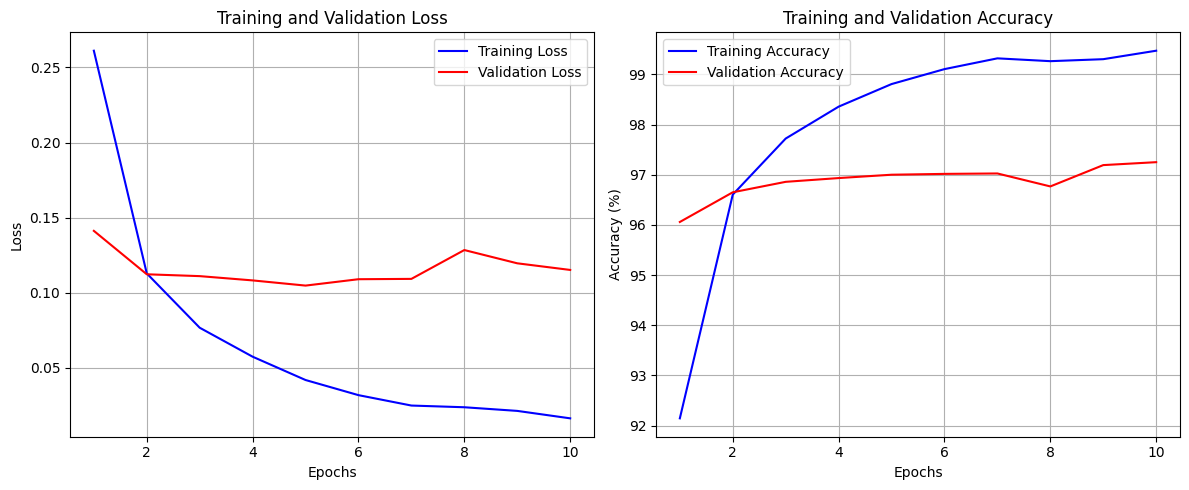

In [ ]:
# Run the entire training pipeline
# This function loads data, builds the model, trains it, and plots results
if __name__ == '__main__':
    main()
